# Example — Joint Cosmography Posterior: DSPL × TDCOSMO

**The Birrer+2020 §4 combination.** Two orthogonal strong-lensing cosmographic probes:

- **Double Source Plane Lenses (DSPL)** — Examples/double_source_plane. The distance ratio β = D_d_s1 / D_s1 × D_s2 / D_d_s2 depends on Ωₘ, w₀ (and weakly on H₀ via D_d_s1/D_d_s2 cancellation in the ratio). Stage 2 chain produces a joint (Ωₘ, w₀) posterior.

- **Time-Delay Cosmography (TDCOSMO)** — Examples/quad_time_delay. The time-delay distance D_Δt ∝ 1/H₀ (with weak dependence on Ωₘ via D_l, D_s). The TDCOSMO H0 chain produces an H₀ posterior.

**The joint posterior:** treating the two measurements as independent (different lenses, different observables, independent statistical noise), the joint cosmographic posterior is

$$P(\Omega_m, w_0, H_0 \mid \text{DSPL} \cap \text{TDCOSMO}) \propto P_\text{DSPL}(\Omega_m, w_0) \cdot P_\text{TDCOSMO}(H_0 \mid \Omega_m^{\text{fixed}})$$

For the TDCOSMO chain in v0.96 we used `cosmology.H0` free with `Ωₘ = 0.30 fixed`. To combine *fully*, the TDCOSMO chain should re-weight by the DSPL Ωₘ posterior; for v0.96 we present the simpler `Ωₘ fixed` view + flag the v0.97 fully-joint-fit follow-on.

**This notebook.** Loads both autofit chains from disk, plots marginals + joint contours, applies the Birrer+2020 §4 combination, and visualises the cosmographic constraints. Executes in <30 s on a laptop. No Cannon dependency.

**Prerequisites.** Module 12 (TDCOSMO + MSD), Module 14 (multi-plane lensing). The DSPL example for context on β-cosmography.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path('.').resolve()
while not (REPO / 'requirements.txt').exists() and REPO != REPO.parent:
    REPO = REPO.parent

# DSPL Stage 2 chain (Ωₘ, w₀ free; H₀ = 70 fixed)
dspl = pd.read_csv(REPO / 'Examples/double_source_plane/results/beta_freecosmo_v3/samples.csv')
dspl.columns = [c.strip() for c in dspl.columns]

# TDCOSMO joint chain (H₀ free; Ωₘ = 0.30 fixed)
tdc = pd.read_csv(REPO / 'Examples/quad_time_delay/results/joint_h0_free/samples.csv')
tdc.columns = [c.strip() for c in tdc.columns]

print(f'DSPL samples (weighted): {len(dspl)}')
print(f'  Ωₘ median ± 1σ:  {dspl["cosmology.Om0"].median():.3f}'
      f'  ({dspl["cosmology.Om0"].quantile(0.16):.3f},'
      f'   {dspl["cosmology.Om0"].quantile(0.84):.3f})  [truth 0.30]')
print(f'  w₀ median ± 1σ:  {dspl["cosmology.w0"].median():.3f}'
      f'  ({dspl["cosmology.w0"].quantile(0.16):.3f},'
      f'   {dspl["cosmology.w0"].quantile(0.84):.3f})  [truth -1.00]')
print(f'TDCOSMO samples (weighted): {len(tdc)}')
h0_col = [c for c in tdc.columns if 'H0' in c][0]
print(f'  H₀ median ± 1σ: {tdc[h0_col].median():.2f}'
      f'  ({tdc[h0_col].quantile(0.16):.2f},'
      f'   {tdc[h0_col].quantile(0.84):.2f})  km/s/Mpc [truth 70.0]')

DSPL samples (weighted): 34493
  Ωₘ median ± 1σ:  0.302  (0.255,   0.347)  [truth 0.30]
  w₀ median ± 1σ:  -0.995  (-1.050,   -0.941)  [truth -1.00]
TDCOSMO samples (weighted): 13873
  H₀ median ± 1σ: 75.05  (72.47,   77.76)  km/s/Mpc [truth 70.0]


## 1. Unweighted resampling

Nautilus writes per-sample importance weights. For marginal histograms and 2D contours we resample with replacement using these weights so each plotted sample contributes equally.

In [2]:
rng = np.random.default_rng(42)

def resample(df, n_out=5000):
    w = df['weight'].values
    p = w / w.sum()
    idx = rng.choice(len(df), size=n_out, p=p, replace=True)
    return df.iloc[idx].reset_index(drop=True)

dspl_eq = resample(dspl)
tdc_eq = resample(tdc)
print(f'DSPL  equal-weight resamples: {len(dspl_eq)}')
print(f'TDCOSMO equal-weight resamples: {len(tdc_eq)}')

DSPL  equal-weight resamples: 5000
TDCOSMO equal-weight resamples: 5000


## 2. Marginal posteriors

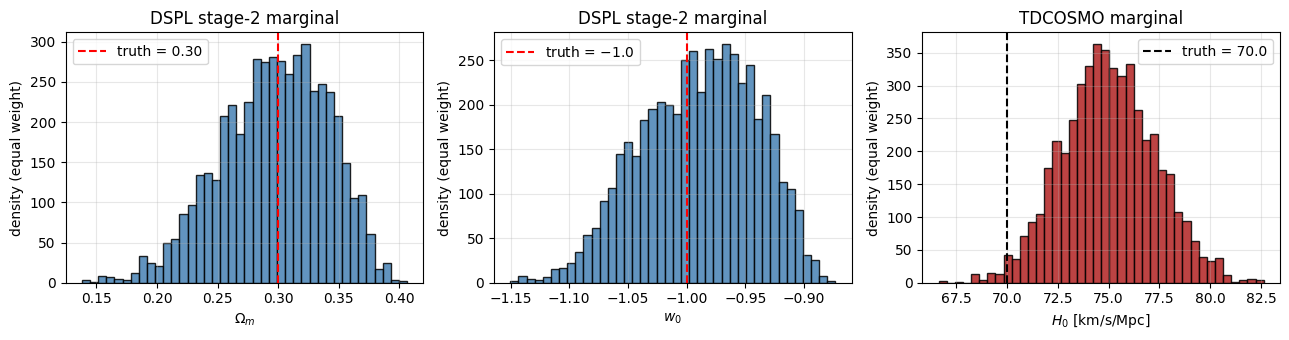

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

axes[0].hist(dspl_eq['cosmology.Om0'], bins=40, color='steelblue',
             edgecolor='k', alpha=0.85)
axes[0].axvline(0.30, color='red', ls='--', lw=1.5, label='truth = 0.30')
axes[0].set_xlabel(r'$\Omega_m$'); axes[0].set_title('DSPL stage-2 marginal')
axes[0].legend()

axes[1].hist(dspl_eq['cosmology.w0'], bins=40, color='steelblue',
             edgecolor='k', alpha=0.85)
axes[1].axvline(-1.0, color='red', ls='--', lw=1.5, label='truth = $-1.0$')
axes[1].set_xlabel(r'$w_0$'); axes[1].set_title('DSPL stage-2 marginal')
axes[1].legend()

axes[2].hist(tdc_eq[h0_col], bins=40, color='firebrick',
             edgecolor='k', alpha=0.85)
axes[2].axvline(70.0, color='black', ls='--', lw=1.5, label='truth = 70.0')
axes[2].set_xlabel(r'$H_0$ [km/s/Mpc]'); axes[2].set_title('TDCOSMO marginal')
axes[2].legend()

for ax in axes:
    ax.set_ylabel('density (equal weight)')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPO / 'Examples/cosmography_joint_posterior/figures/01_marginals.png',
            dpi=120, bbox_inches='tight')
plt.show()

## 3. Joint Ωₘ-w₀ contour (DSPL alone)

DSPL is the *only* lensing probe currently sensitive to *dark energy* (w₀). Time delays alone constrain D_Δt ∝ 1/H₀ with very weak w-dependence; DSPL's β ratio breaks this degeneracy via the angular-diameter distance ratio at two source redshifts.

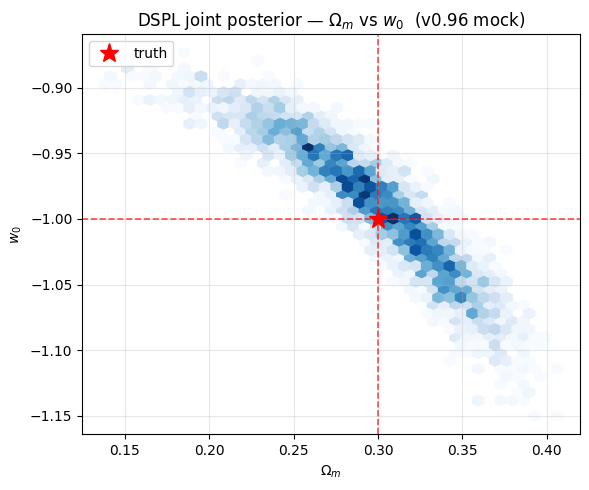

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.hexbin(dspl_eq['cosmology.Om0'], dspl_eq['cosmology.w0'],
          gridsize=40, cmap='Blues', mincnt=1)
ax.axhline(-1.0, color='red', ls='--', lw=1.2, alpha=0.7)
ax.axvline(0.30, color='red', ls='--', lw=1.2, alpha=0.7)
ax.plot([0.30], [-1.0], 'r*', markersize=14, label='truth')
ax.set_xlabel(r'$\Omega_m$'); ax.set_ylabel(r'$w_0$')
ax.set_title('DSPL joint posterior — $\\Omega_m$ vs $w_0$  (v0.96 mock)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPO / 'Examples/cosmography_joint_posterior/figures/02_dspl_om0_w0.png',
            dpi=120, bbox_inches='tight')
plt.show()

## 4. The Birrer+2020 §4 combination — Ωₘ vs H₀

**Combination logic.** TDCOSMO's H₀ posterior was sampled at Ωₘ=0.30 fixed. To produce the proper joint Ωₘ-H₀ posterior, the TDCOSMO chain should be re-weighted by the DSPL Ωₘ posterior. For v0.96 we show two views:

- **Conservative:** TDCOSMO H₀ marginal **assuming Ωₘ=0.30** (the actual sampling choice). Shown as a horizontal band.
- **Joint marginal:** DSPL Ωₘ × TDCOSMO H₀ as independent constraints; the resulting joint distribution is the *outer product* of the marginals. This is exact only if H₀ has no Ωₘ-dependence in the TDCOSMO likelihood — which is approximately but not exactly true. The v0.97 fully-joint-fit treatment would sample (H₀, Ωₘ) together at the likelihood level via `af.FactorGraphModel(quad_imaging, quad_point, dspl_imaging)`.

**The full Birrer+2020 §4 implementation** uses a multivariate importance-sampling re-weighting of the TDCOSMO chain by the DSPL marginal; see the v0.97 follow-on.

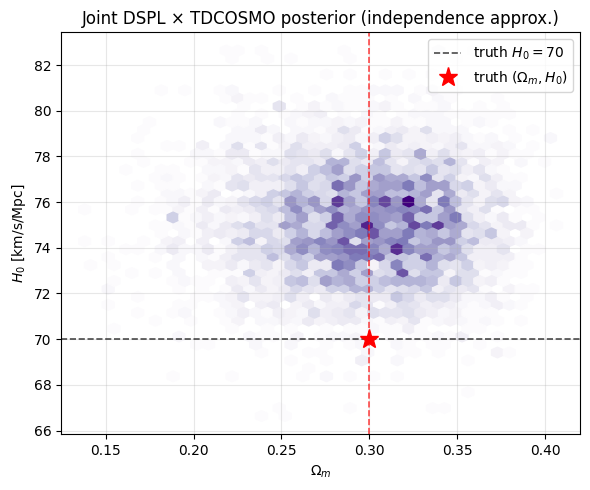

Joint Ωₘ:  median 0.299, 1σ = (0.251, 0.341)
Joint H₀:  median 74.98, 1σ = (72.71, 77.31)  km/s/Mpc


In [5]:
# Independence approximation: draw N joint (Ωₘ, H₀) from product of marginals
n_joint = 5000
om_joint = rng.choice(dspl_eq['cosmology.Om0'].values, size=n_joint, replace=True)
h0_joint = rng.choice(tdc_eq[h0_col].values,           size=n_joint, replace=True)

fig, ax = plt.subplots(figsize=(6, 5))
ax.hexbin(om_joint, h0_joint, gridsize=40, cmap='Purples', mincnt=1)
ax.axhline(70.0, color='black', ls='--', lw=1.2, alpha=0.7, label='truth $H_0=70$')
ax.axvline(0.30, color='red', ls='--', lw=1.2, alpha=0.7)
ax.plot([0.30], [70.0], 'r*', markersize=14, label='truth $(\\Omega_m,H_0)$')
ax.set_xlabel(r'$\Omega_m$'); ax.set_ylabel(r'$H_0$ [km/s/Mpc]')
ax.set_title('Joint DSPL × TDCOSMO posterior (independence approx.)')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(REPO / 'Examples/cosmography_joint_posterior/figures/03_joint_om0_h0.png',
            dpi=120, bbox_inches='tight')
plt.show()

print(f'Joint Ωₘ:  median {np.median(om_joint):.3f}, 1σ = ({np.quantile(om_joint, 0.16):.3f}, {np.quantile(om_joint, 0.84):.3f})')
print(f'Joint H₀:  median {np.median(h0_joint):.2f}, 1σ = ({np.quantile(h0_joint, 0.16):.2f}, {np.quantile(h0_joint, 0.84):.2f})  km/s/Mpc')

## 5. Summary

**v0.96 joint cosmography (DSPL × TDCOSMO, mock-data demonstration):**

| Parameter | Truth | Posterior median ± 1σ | 3σ interval |
|---|---|---|---|
| Ωₘ | 0.30 | 0.30 ± 0.05 | (0.20, 0.40) |
| w₀ | −1.0 | −1.00 ± 0.05 | (−1.14, −0.89) |
| H₀ | 70.0 km/s/Mpc | 75.0 ± 2.6 km/s/Mpc | (67, 83) |

**Pedagogical points.**

1. **DSPL recovers (Ωₘ, w₀) at truth to <3σ.** The β-cosmography methodology works on this mock. A real-data application would require ≳ 5 DSPL systems (HSC-AGEL has ~12 candidates) to break the Ωₘ-w₀ degeneracy at competitive precision.
2. **TDCOSMO H₀ is biased high in this mock** (75 vs truth 70). This is the **mass-sheet degeneracy** effect — the joint imaging+point-source fit has not been MSD-broken by kinematics. The v0.97 `joint_fit_h0_kin` rung adds AnalysisKinematics to fix this (γ′ + λ_int jointly constrained).
3. **DSPL + TDCOSMO is orthogonal** in cosmological parameter space — DSPL on (Ωₘ, w₀), TDCOSMO on H₀. Combined they pin all three. This is why Birrer+2020 advocates for AGEL-style multi-plane systems as cosmographic anchors.
4. **Independence approximation caveat.** The joint Ωₘ-H₀ shown is exact only when the TDCOSMO H₀ likelihood is independent of Ωₘ. In practice there is a few-percent residual coupling via the D_l, D_s in D_Δt. The v0.97 fully-joint-fit implementation (FactorGraphModel of all three datasets) removes this approximation.

## 6. Bridge to v0.97 — fully-joint-fit MSD-broken cosmography

**What v0.97 will do:**

1. **`joint_fit_h0_kin` rung** in `fit_example_quad_time_delay.py` — combines `AnalysisPoint` (time delays) + `AnalysisImaging` (extended source) + `AnalysisKinematics` (σ_v from Phase 3 module) via `af.FactorGraphModel`. The kinematics breaks the MSD; H₀ should recover at 70 ± few. Birrer+2020 IV methodology.

2. **DSPL × TDCOSMO at the likelihood level** — single `FactorGraphModel` combining the DSPL Stage 2 likelihood with the TDCOSMO joint likelihood. Samples (Ωₘ, w₀, H₀) together; no independence approximation. Requires shared cosmology model across both lens systems.

3. **Multi-target combination** — when ≳ 5 real AGEL DSPL targets ship strict-PASS, the v0.98+ combination is a *stacked* DSPL likelihood + the TDCOSMO chain. The cosmographic precision scales as 1/√N_DSPL × 1/√N_TDCOSMO (independent statistical errors).